# 決定木を用いた飲食店推薦アルゴリズムの提案

## 1. データの読み込み

In [238]:
import numpy as np
import json
from Users import GetLabels

user1_ratings, user2_ratings, user3_ratings= GetLabels.getLabels()

with open('Restaurants/Features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

feature_names = [
        "中華", "居酒屋", "ダイニングバー・バル", "和食", 
        "お好み焼き・もんじゃ", "韓国料理", "イタリアン・フレンチ", 
        "焼肉・ホルモン", "洋食", "アジア・エスニック料理", 
        "創作料理", "各国料理", "ラーメン","予算","個室", "喫煙","wifi",
        "カード", "駐車場", "総合評価"
    ]

#numpy形式に変換
features_np = np.array(features)
user1_ratings_np = np.array(user1_ratings)
user2_ratings_np = np.array(user2_ratings)
user3_ratings_np = np.array(user3_ratings)

### 結果を格納する辞書の定義

In [239]:
# ユーザー名
user_names = ['User1', 'User2', 'User3']

# 各モデルの名前
model_names = ["Random", "Decision Tree", "Logistic Regression", "k-NN"]

#結果を格納する辞書
results = {
    "User1": {
        "Random": {"Precision": [], "Recall": [1]*10},
        "Decision Tree": {"Precision": [], "Recall": []},
        "Logistic Regression": {"Precision": [], "Recall": []},
        "k-NN": {"Precision": [], "Recall": []}
    },
    "User2": {
        "Random": {"Precision": [], "Recall": [1]*10},
        "Decision Tree": {"Precision": [], "Recall": []},
        "Logistic Regression": {"Precision": [], "Recall": []},
        "k-NN": {"Precision": [], "Recall": []}
    },
    "User3": {
        "Random": {"Precision": [], "Recall": [1]*10},
        "Decision Tree": {"Precision": [], "Recall": []},
        "Logistic Regression": {"Precision": [], "Recall": []},
        "k-NN": {"Precision": [], "Recall": []}
    }  
}

## 2. 10フォールド交差検証
### 目的
- 決定木を用いた手法の汎化性能を評価するため.

User1


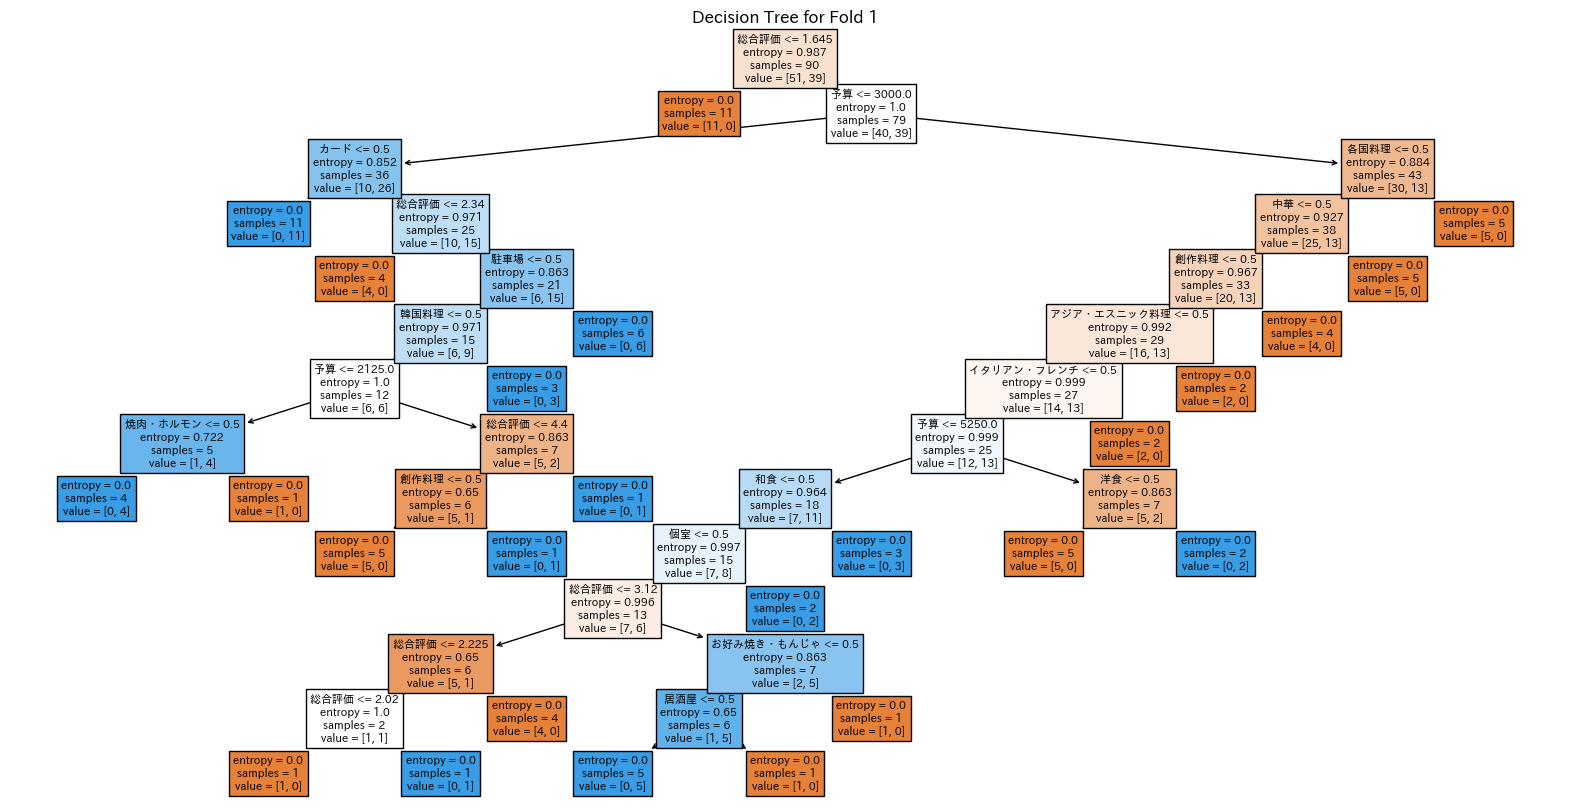

Mean Precision across all folds: 0.7364285714285714
Mean Recall across all folds: 0.6354761904761904
Mean Random Precision across all folds: 0.43999999999999995

User2


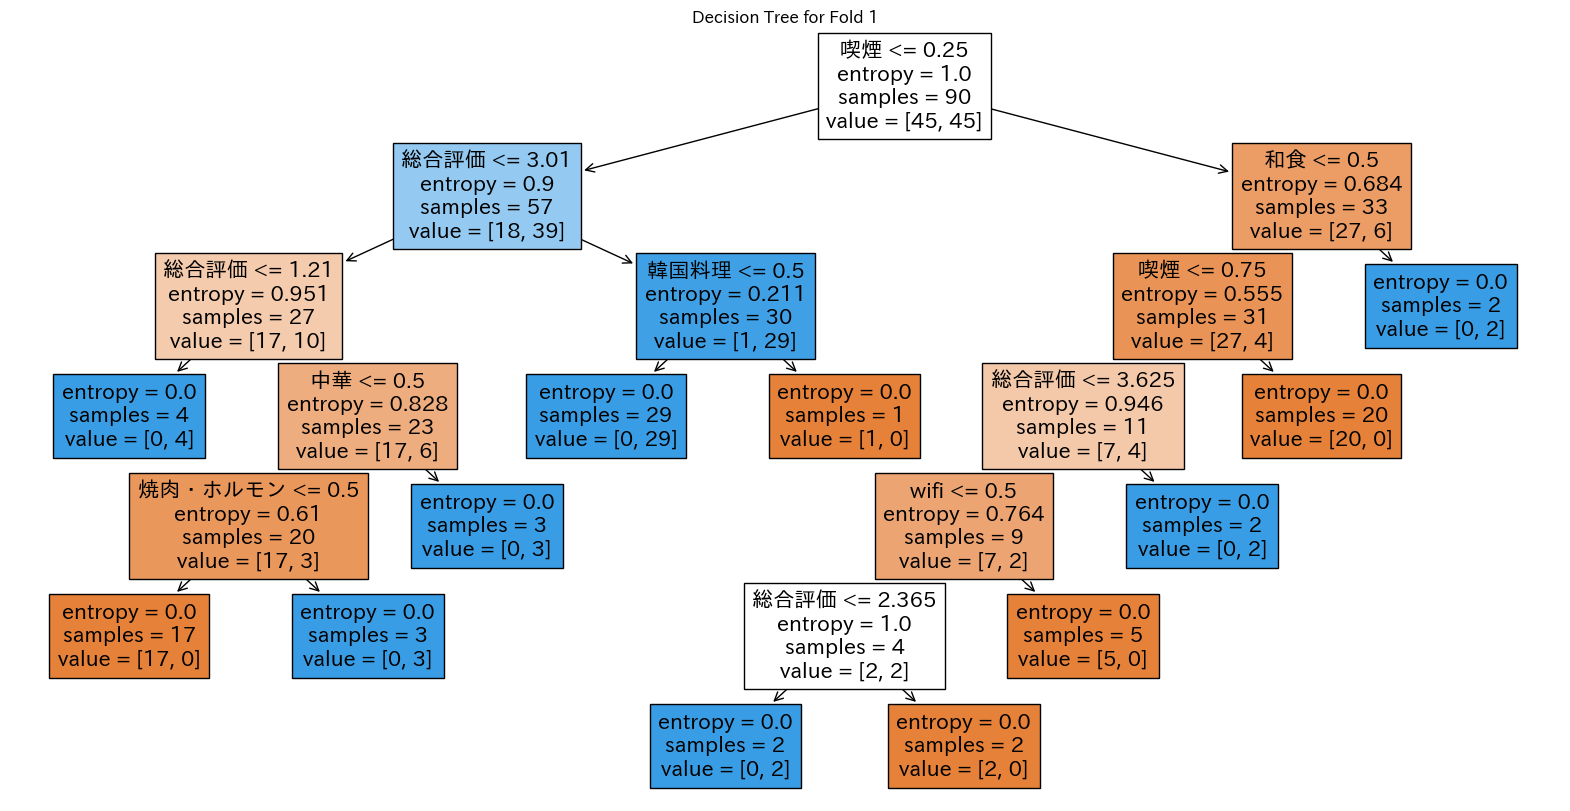

Mean Precision across all folds: 0.9607142857142857
Mean Recall across all folds: 0.9321428571428572
Mean Random Precision across all folds: 0.48

User3


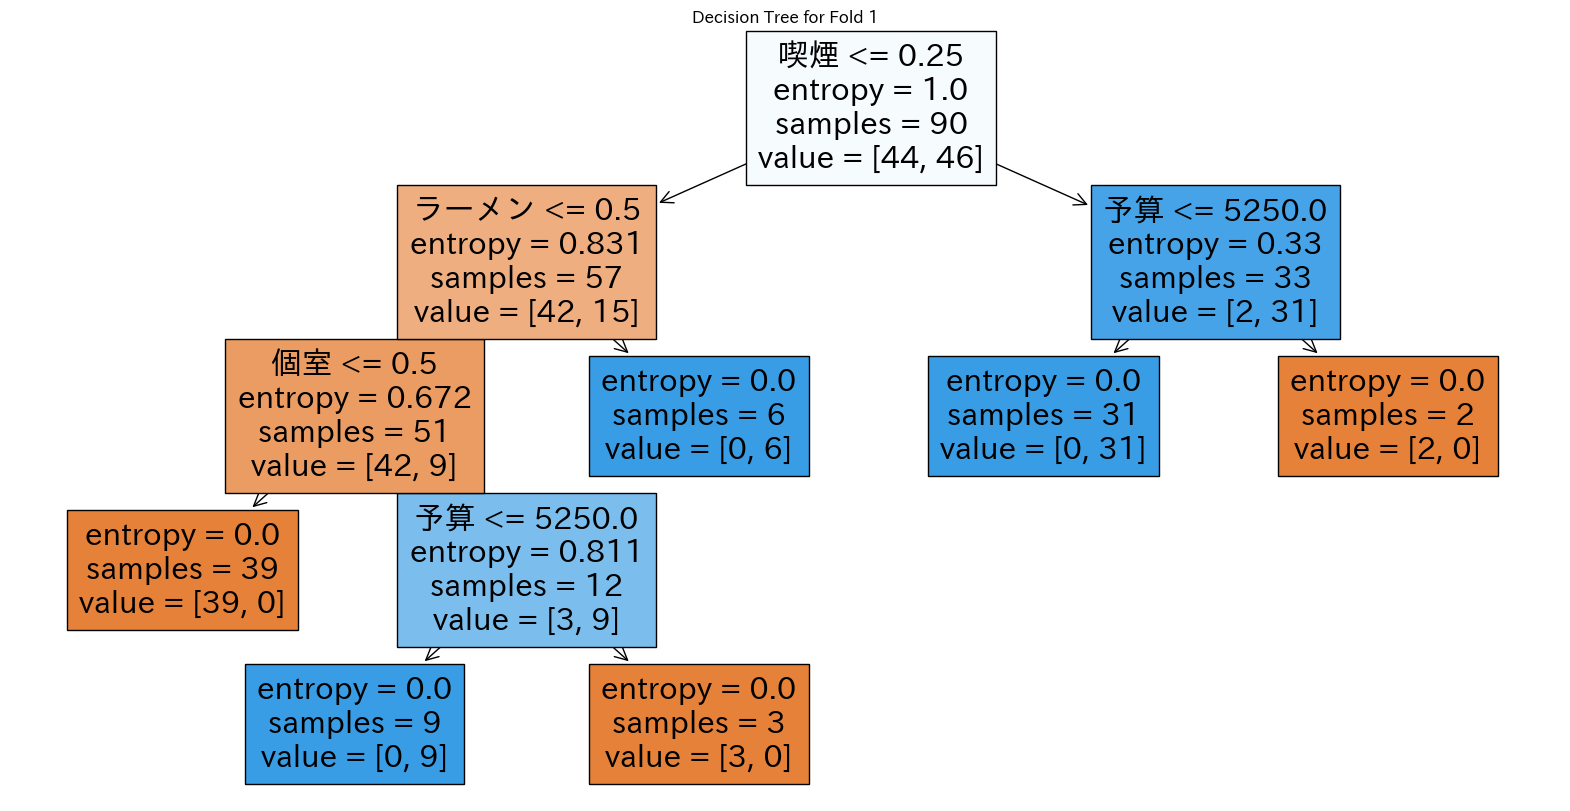

Mean Precision across all folds: 0.8833333333333334
Mean Recall across all folds: 0.9
Mean Random Precision across all folds: 0.48999999999999994



In [240]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import japanize_matplotlib

 # KFoldインスタンスを初期化
kf = KFold(n_splits=10, shuffle=True, random_state=40)

# NumPy配列をリスト形式の文字列に変換する関数
def array_to_list_string(array):
    formatted_array = []
    for elem in array:
        if np.isclose(elem, np.round(elem)):
            # np.iscloseで浮動小数点数が整数に近いか確認し、整数に変換
            formatted_array.append(str(int(np.round(elem))))
        else:
            # 浮動小数点数はそのままの形式で追加
            formatted_array.append(str(elem))
    return '[' + ', '.join(formatted_array) + ']'

def crossValidation(user_ratings_np, user_name):
    dtc = DecisionTreeClassifier(random_state=42, criterion='entropy')

    # フォールド番号を1から始めるためのカウンター
    fold_counter = 1

    # KFoldで分割されたインデックスを使ってループ
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成します。
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

        # 決定木の分類器を作成し、トレーニングデータにフィット
        dtc.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = dtc.predict(X_test)

        # 適合率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions, zero_division=0)
        recall = recall_score(y_test, predictions, zero_division=0)
        
        # 再現率を計算し、リストに追加
        results[user_name]["Decision Tree"]["Precision"].append(precision)
        results[user_name]["Decision Tree"]["Recall"].append(recall)

        # テストセットに含まれる陽性クラスの割合を計算し、リストに追加
        positive_class_ratio = np.mean(y_test)
        results[user_name]["Random"]["Precision"].append(positive_class_ratio)

        # 決定木のプロット
        if fold_counter == 1: 
            plt.figure(figsize=(20,10))
            plot_tree(dtc, filled=True, feature_names=feature_names)
            plt.title(f'Decision Tree for Fold {fold_counter}')
            plt.show()
        
        # 次のフォールドへのカウンターを増やす
        fold_counter += 1

    # 全フォールドでの平均正解率を出力
    mean_precision = np.mean(results[user_name]["Decision Tree"]["Precision"])
    mean_recall = np.mean(results[user_name]["Decision Tree"]["Recall"])
    mean_random_precisions = np.mean(results[user_name]["Random"]["Precision"])
    print(f'Mean Precision across all folds: {mean_precision}')
    print(f'Mean Recall across all folds: {mean_recall}')
    print(f'Mean Random Precision across all folds: {mean_random_precisions}\n')

print("User1")
crossValidation(user1_ratings_np, "User1")
print("User2")
crossValidation(user2_ratings_np, "User2")
print("User3")
crossValidation(user3_ratings_np, "User3")

### 結果
- 全てのユーザーにおいて, ランダム手法よりも平均適合率が良いことが分かった.

## 3. 訓練データを増やした精度の推移
### 目的
- 訓練データを増やした際に, どの程度性能が上がるかどうかを調べる.

In [241]:
final_precisions = {
    "Random": {"User1": [], "User2": [], "User3": []},
    "Decision Tree": {"User1": [], "User2": [], "User3": []},
    "Logistic Regression": {"User1": [], "User2": [], "User3": []},
    "k-NN": {"User1": [], "User2": [], "User3": []} 
}

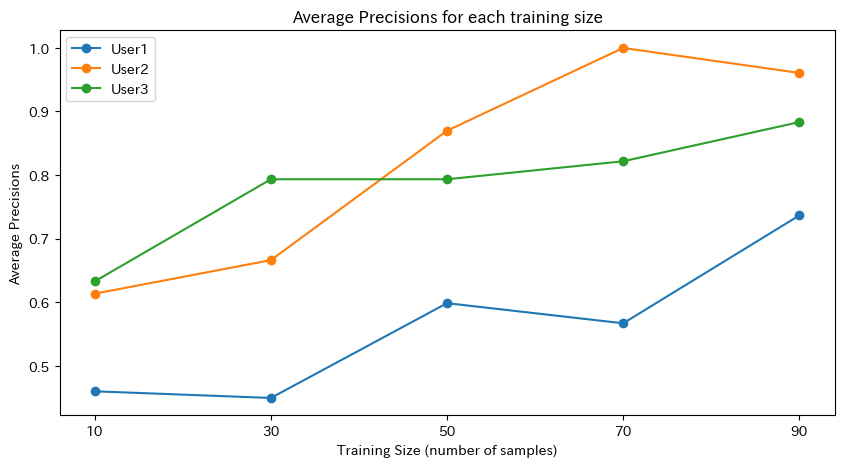

In [242]:
training_sizes = [10, 30, 50, 70, 90]
def train(user_ratings_np):
    dtc = DecisionTreeClassifier(random_state=42, criterion='entropy')
    
    mean_precisions = {size: [] for size in training_sizes}
    mean_recalls = {size: [] for size in training_sizes}

    for train_index, test_index in kf.split(features_np):
        # テストデータを固定
        X_test, y_test = features_np[test_index], user_ratings_np[test_index]

        for size in training_sizes:
            # 訓練データを指定されたサイズで取得
            X_train = features_np[train_index[:size]]
            y_train = user_ratings_np[train_index[:size]]

            # モデルを訓練
            dtc.fit(X_train, y_train)

            # テストデータに対する予測
            predictions = dtc.predict(X_test)

            # 適合率を計算
            precision = precision_score(y_test, predictions, zero_division=0)
            # 再現率を計算
            recall = recall_score(y_test, predictions, zero_division=0)

            # スコアをリストに追加
            mean_precisions[size].append(precision)
            mean_recalls[size].append(recall)

    # 各訓練サイズについて平均精度を計算
    final_precisions = [np.mean(mean_precisions[size]) for size in training_sizes]

    return final_precisions

final_precisions["Decision Tree"]["User1"] = train(user1_ratings_np)
final_precisions["Decision Tree"]["User2"] = train(user2_ratings_np)
final_precisions["Decision Tree"]["User3"] = train(user3_ratings_np)

# 適合率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, final_precisions["Decision Tree"]["User1"], label='User1', marker='o')
plt.plot(training_sizes, final_precisions["Decision Tree"]["User2"], label='User2', marker='o')
plt.plot(training_sizes, final_precisions["Decision Tree"]["User3"], label='User3', marker='o')
plt.title('Average Precisions for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Precisions')
plt.xticks(training_sizes)
plt.legend()
plt.show()

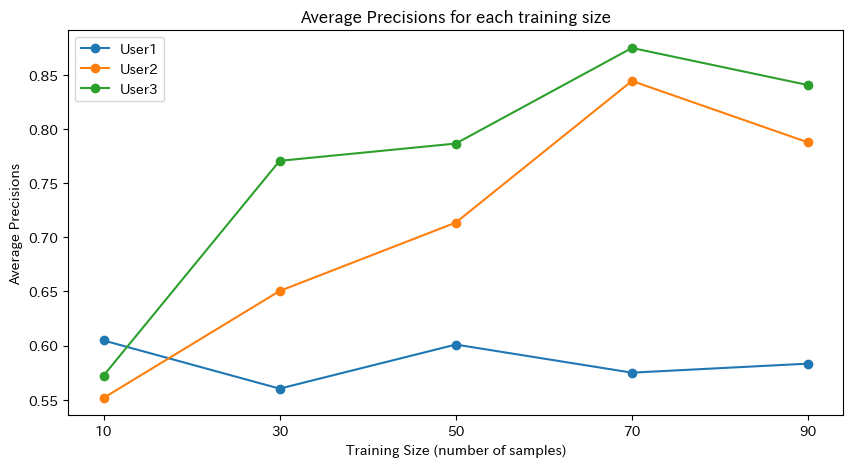

In [243]:
from sklearn.linear_model import LogisticRegression

def train(user_ratings_np, user_name):
    
    mean_accuracies = {size: [] for size in training_sizes}
    mean_precisions = {size: [] for size in training_sizes}
    mean_recalls = {size: [] for size in training_sizes}
    mean_f1s = {size: [] for size in training_sizes}

    for train_index, test_index in kf.split(features_np):
        # テストデータを固定
        X_test, y_test = features_np[test_index], user_ratings_np[test_index]

        for size in training_sizes:
            # 訓練データを指定されたサイズで取得
            X_train = features_np[train_index[:size]]
            y_train = user_ratings_np[train_index[:size]]

            # モデルを訓練
            # ロジスティック回帰を訓練
            lr = LogisticRegression(random_state=42,max_iter=500)
            lr.fit(X_train, y_train)

            # テストデータに対する予測
            predictions = lr.predict(X_test)

            precision = precision_score(y_test, predictions, zero_division=0)
            recall = recall_score(y_test, predictions, zero_division=0)

            # スコアをリストに追加
            mean_precisions[size].append(precision)
            mean_recalls[size].append(recall)
            
    results[user_name]["Logistic Regression"]["Precision"].extend(mean_precisions[90])
    results[user_name]["Logistic Regression"]["Recall"].extend(mean_recalls[90])

    # 各訓練サイズについて平均スコアを計算
    final_precisions = [np.mean(mean_precisions[size]) for size in training_sizes]

    return final_precisions

final_precisions["Logistic Regression"]["User1"] = train(user1_ratings_np, "User1")
final_precisions["Logistic Regression"]["User2"] = train(user2_ratings_np, "User2")
final_precisions["Logistic Regression"]["User3"] = train(user3_ratings_np, "User3")

# 適合率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, final_precisions["Logistic Regression"]["User1"], label='User1', marker='o')
plt.plot(training_sizes, final_precisions["Logistic Regression"]["User2"], label='User2', marker='o')
plt.plot(training_sizes, final_precisions["Logistic Regression"]["User3"], label='User3', marker='o')
plt.title('Average Precisions for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Precisions')
plt.xticks(training_sizes)
plt.legend()
plt.show()

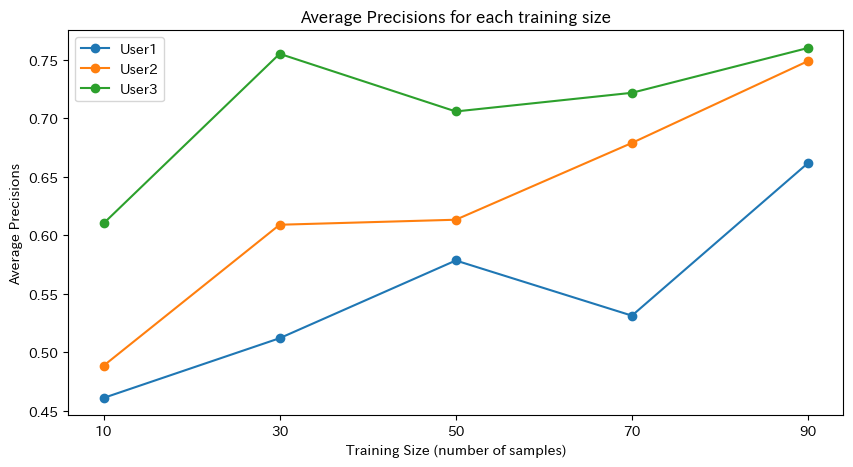

In [244]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

def train(user_ratings_np, user_name):
    
    mean_accuracies = {size: [] for size in training_sizes}
    mean_precisions = {size: [] for size in training_sizes}
    mean_recalls = {size: [] for size in training_sizes}
    mean_f1s = {size: [] for size in training_sizes}

    scaler = MinMaxScaler()

    # 価格帯と総合評価の列のインデックス（0ベースのインデックスを使用）
    price_index = 13
    rating_index = 19
    
    # スケーリングする前の元のデータを別の変数にコピー
    features_scaled = np.copy(features_np)
    
    # 価格帯と総合評価の列をスケーリング
    features_scaled[:, [price_index, rating_index]] = scaler.fit_transform(features_scaled[:, [price_index, rating_index]])

    # グリッドサーチ用のパラメータ範囲を設定
    param_grid = {'n_neighbors': range(1, 10)}

    # グリッドサーチの初期化（KFoldオブジェクトを使用）
    grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=kf, scoring='accuracy')

    # グリッドサーチの実行
    grid_search.fit(features_scaled, user_ratings_np)

    # 最適なモデルを取得
    best_knn = grid_search.best_estimator_

    for train_index, test_index in kf.split(features_np):
        # テストデータを固定
        X_test, y_test = features_scaled[test_index], user_ratings_np[test_index]

        for size in training_sizes:
            # 訓練データを指定されたサイズで取得
            X_train = features_scaled[train_index[:size]]
            y_train = user_ratings_np[train_index[:size]]

            # モデルを訓練
            best_knn.fit(X_train, y_train)

            # テストデータに対する予測
            predictions = best_knn.predict(X_test)

            precision = precision_score(y_test, predictions, zero_division=0)
            recall = recall_score(y_test, predictions, zero_division=0)

            # スコアをリストに追加
            mean_precisions[size].append(precision)
            mean_recalls[size].append(recall)
            
    results[user_name]["k-NN"]["Precision"].extend(mean_precisions[90])
    results[user_name]["k-NN"]["Recall"].extend(mean_recalls[90])

    # 各訓練サイズについて平均スコアを計算
    final_precisions = [np.mean(mean_precisions[size]) for size in training_sizes]

    return final_precisions

final_precisions["k-NN"]["User1"] = train(user1_ratings_np, "User1")
final_precisions["k-NN"]["User2"] = train(user2_ratings_np, "User2")
final_precisions["k-NN"]["User3"] = train(user3_ratings_np, "User3")

# 適合率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, final_precisions["k-NN"]["User1"], label='User1', marker='o')
plt.plot(training_sizes, final_precisions["k-NN"]["User2"], label='User2', marker='o')
plt.plot(training_sizes, final_precisions["k-NN"]["User3"], label='User3', marker='o')
plt.title('Average Precisions for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Precisions')
plt.xticks(training_sizes)
plt.legend()
plt.show()

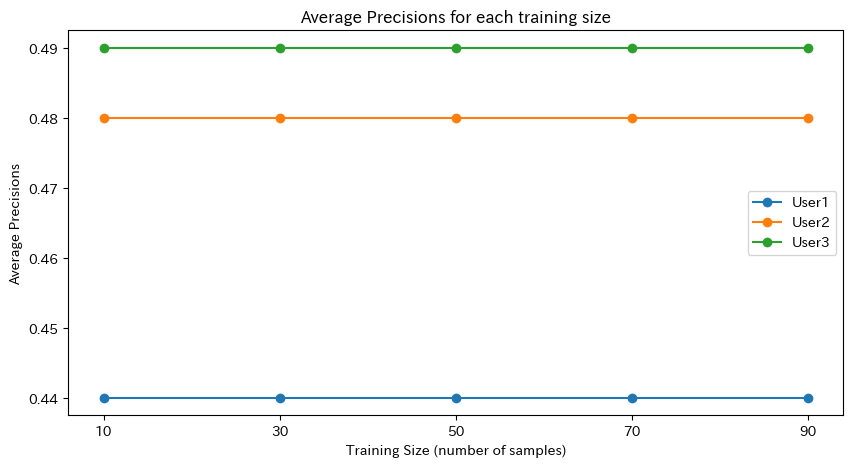

In [245]:
final_precisions["Random"]["User1"] = [np.mean(results["User1"]["Random"]["Precision"])]*5
final_precisions["Random"]["User2"] = [np.mean(results["User2"]["Random"]["Precision"])]*5
final_precisions["Random"]["User3"] = [np.mean(results["User3"]["Random"]["Precision"])]*5

# 適合率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, final_precisions["Random"]["User1"], label='User1', marker='o')
plt.plot(training_sizes, final_precisions["Random"]["User2"], label='User2', marker='o')
plt.plot(training_sizes, final_precisions["Random"]["User3"], label='User3', marker='o')
plt.title('Average Precisions for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Precisions')
plt.xticks(training_sizes)
plt.legend()
plt.show()

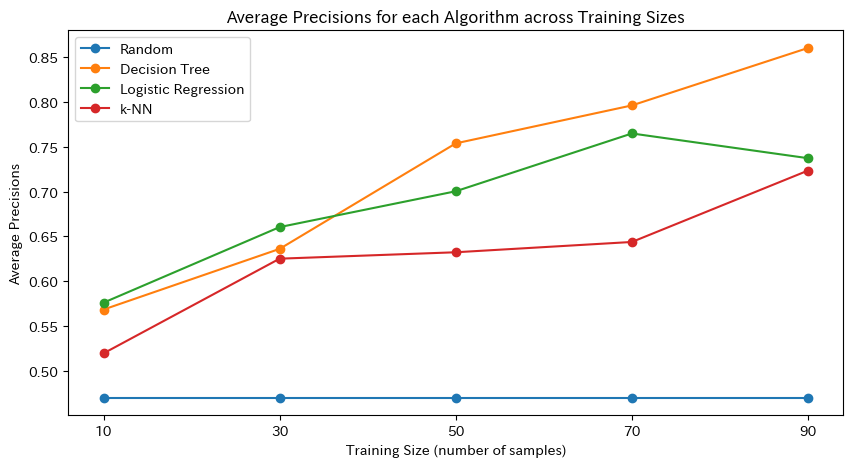

In [246]:
# 各アルゴリズムの平均適合率をプロット
plt.figure(figsize=(10, 5))
for algorithm in final_precisions:
    # ユーザーごとの平均適合率の計算
    mean_precisions = [np.mean([final_precisions[algorithm][user][i] for user in final_precisions[algorithm]]) for i in range(len(training_sizes))]
    plt.plot(training_sizes, mean_precisions, label=algorithm, marker='o')

plt.title('Average Precisions for each Algorithm across Training Sizes')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Precisions')
plt.xticks(training_sizes)
plt.legend()
plt.show()

### 結果
- 訓練データが増えれば, 性能が上がるということが分かった

## 4. 他の手法との比較
- ロジスティック回帰を用いた手法, k-NNを用いた手法と性能を比較する

### 目的
- より分かりやすいアルゴリズムの評価にすること.

User1
Random
Mean Accuracy: 0.8, Mean Precision: 0.43999999999999995, Mean Recall: 1.0, Mean_F1: 0.7094988344988344

Decision Tree
Mean Accuracy: 0.8, Mean Precision: 0.7364285714285714, Mean Recall: 0.6354761904761904, Mean_F1: 0.7094988344988344

Logistic Regression
Mean Accuracy: 0.8, Mean Precision: 0.5833333333333333, Mean Recall: 0.6335714285714286, Mean_F1: 0.7094988344988344

k-NN
Mean Accuracy: 0.8, Mean Precision: 0.6616666666666667, Mean Recall: 0.4969047619047619, Mean_F1: 0.7094988344988344

User2
Random
Mean Accuracy: 0.8, Mean Precision: 0.48, Mean Recall: 1.0, Mean_F1: 0.7094988344988344

Decision Tree
Mean Accuracy: 0.8, Mean Precision: 0.9607142857142857, Mean Recall: 0.9321428571428572, Mean_F1: 0.7094988344988344

Logistic Regression
Mean Accuracy: 0.8, Mean Precision: 0.7877380952380952, Mean Recall: 0.866904761904762, Mean_F1: 0.7094988344988344

k-NN
Mean Accuracy: 0.8, Mean Precision: 0.7488095238095238, Mean Recall: 0.7792857142857142, Mean_F1: 0.70949883449883

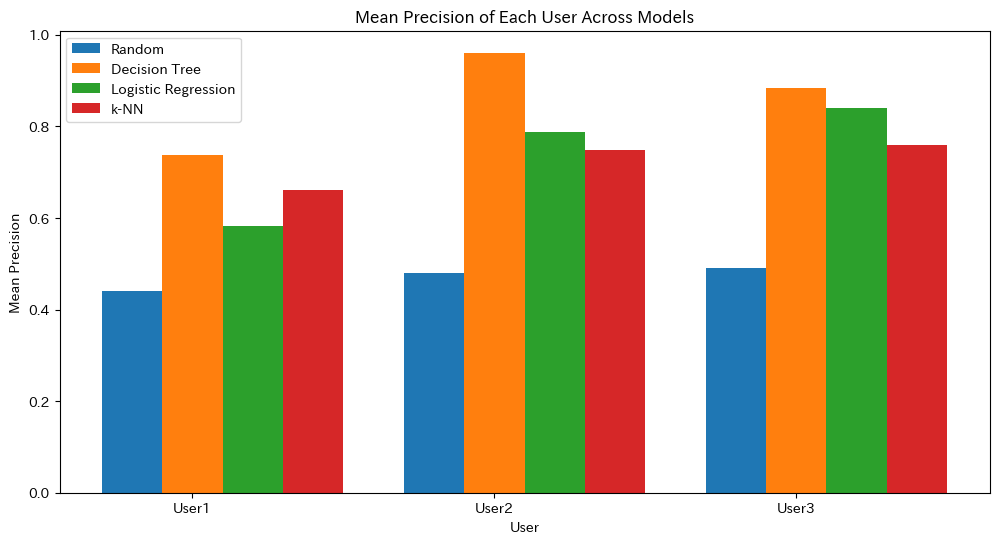

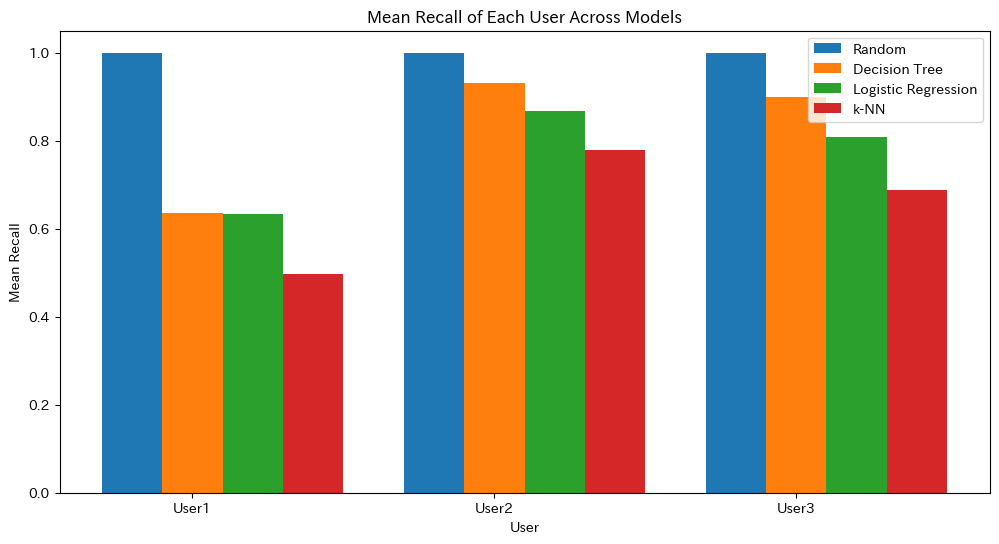

In [247]:
# 事前に定義されたresults辞書を使用して各スコアの平均値を計算し、出力
for user_name in user_names:
    print(user_name)
    for model_name in model_names:
        mean_precision = np.mean(results[user_name][model_name]["Precision"])
        mean_recall = np.mean(results[user_name][model_name]["Recall"])
        
        print(f"{model_name}\nMean Accuracy: {mean_accuracy}, Mean Precision: {mean_precision}, Mean Recall: {mean_recall}, Mean_F1: {mean_f1}\n")

# X軸の位置
index = np.arange(len(user_names))
# 棒グラフの設定
bar_width = 0.2

# 各ユーザーの適合率をプロット
plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_names):
    user_precision = [np.mean(results[user][model_name]['Precision']) for user in user_names]
    plt.bar(index + bar_width * i, user_precision, bar_width, label=model_name)

plt.xlabel('User')
plt.ylabel('Mean Precision')
plt.title('Mean Precision of Each User Across Models')
plt.xticks(index + bar_width, user_names)
plt.legend()
plt.show()

# 各ユーザーの再現率をプロット
plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_names):
    user_recall = [np.mean(results[user][model_name]['Recall']) for user in user_names]
    plt.bar(index + bar_width * i, user_recall, bar_width, label=model_name)

plt.xlabel('User')
plt.ylabel('Mean Recall')
plt.title('Mean Recall of Each User Across Models')
plt.xticks(index + bar_width, user_names)
plt.legend()
plt.show()

### 結果
- 決定木は, ロジスティック回帰やk-NNよりも, 性能が良かった.

## 5. シャピロ・ウィルク検定
### 目的
-  得られた適合率データ群が正規分布に従っているかどうかを確認するため.

In [248]:
from scipy import stats

def shapiro(user_name):
    # 検定の実施
    w_stat, p_value = stats.shapiro(results[user_name]["Decision Tree"]["Precision"])

    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")

for user_name in user_names:    
    print(user_name)
    shapiro(user_name)
    print("\n")

User1
検定結果: 統計量 = 0.8579772710800171, p値 = 0.0722263976931572


User2
検定結果: 統計量 = 0.5374100208282471, p値 = 1.0014367035182659e-05


User3
検定結果: 統計量 = 0.44306498765945435, p値 = 7.871774982959323e-07




### 結果
- 決定木モデルでは, User3に対する適合率データ群のp値が0.05以下であったため, 正規分布に従っていないと言える.つまり, ノンパラメトリックな検定を使うべきだということが分かる.

## 6. ウィルコクソンの符号順位検
### 目的
- 片側検定を使って, 決定木を用いた手法と他の手法の適合率に有意差があるかどうか(決定木を用いた手法の方が有効かどうか)を調べるため.

In [251]:
def wilcoxon(user_name, other_precisions):
    # 検定の実施
    w_stat, p_value = stats.wilcoxon(results[user_name]["Decision Tree"]["Precision"], other_precisions, alternative='greater')
    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")
    print("\n")
    
for user_name in user_names:
    print(user_name)
    wilcoxon(user_name, results[user_name]["Random"]["Precision"])

User1
検定結果: 統計量 = 54.0, p値 = 0.001953125


User2
検定結果: 統計量 = 55.0, p値 = 0.0009765625


User3
検定結果: 統計量 = 45.0, p値 = 0.003710480643933249




In [252]:
# 決定木と他の手法（k-NN、ロジスティック回帰）の適合率に有意差があるかを調べる
for user_name in user_names:
    print(f"Results for {user_name}:")
    
    # ロジスティック回帰の適合率
    logistic_precisions = results[user_name]['Logistic Regression']['Precision']
    print("決定木 vs ロジスティック回帰")
    wilcoxon(user_name, logistic_precisions)

    # k-NNの適合率
    knn_precisions = results[user_name]['k-NN']['Precision']
    print("決定木 vs k-NN")
    wilcoxon(user_name, knn_precisions)


Results for User1:
決定木 vs ロジスティック回帰
検定結果: 統計量 = 39.0, p値 = 0.025103876532892727


決定木 vs k-NN
検定結果: 統計量 = 26.0, p値 = 0.1301343913537643


Results for User2:
決定木 vs ロジスティック回帰
検定結果: 統計量 = 27.0, p値 = 0.013995907742832873


決定木 vs k-NN
検定結果: 統計量 = 35.0, p値 = 0.008508686083466901


Results for User3:
決定木 vs ロジスティック回帰
検定結果: 統計量 = 8.0, p値 = 0.13666083914614907


決定木 vs k-NN
検定結果: 統計量 = 15.0, p値 = 0.021557223391537678




## 結果
- ランダム手法との比較: 全てのユーザーにおいて, p値が0.05以下であったため, 有意水準5%で決定木を用いた手法とランダム手法の適合率に有意差があった. つまり, 決定木を用いた手法の方が有効であることが分かる.

- ロジスティック回帰との比較: User2のみにおいて, p値が0.05以下であったため, 有意水準5%で決定木を用いた手法とランダム手法の適合率に有意差があった. つまり, 決定木を用いた手法の方が一定の有効性があることが分かる.

- k-NNとの比較: 全てのユーザーにおいて, p値が0.05以下であったため, 有意水準5%で決定木を用いた手法とランダム手法の適合率に有意差があった. つまり, 決定木を用いた手法の方が有効であることが分かる.